# 04. H3 8 승차인원 변화량 이상치 분석

H3 8 공급구조 유지 셀의 승차인원 변화량에 IQR 기준을 적용하여 이상치 셀을 확인하고 지도에 표시한다.

In [12]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from shapely.geometry import Polygon, mapping
import h3

plt.rcParams['font.family'] = ['Malgun Gothic', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
BASE = Path.cwd()
if BASE.name == 'Analysis': BASE = BASE.parent
OUTPUT_DIR = BASE / 'Analysis' / 'output'
ADMIN_PATH = BASE / 'api_cache_gtx_a_routes' / 'HangJeongDong_ver20260701.geojson'
stable = pd.read_csv(OUTPUT_DIR / 'h3_8_stable_supply_demand_change.csv', encoding='utf-8-sig')
change_col = '승차인원 증감'
q1 = stable[change_col].quantile(0.25)
q3 = stable[change_col].quantile(0.75)
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr
stable['이상치 유형'] = np.select([stable[change_col] < lower_fence, stable[change_col] > upper_fence], ['큰 감소 이상치', '큰 증가 이상치'], default='정상')
outliers = stable[stable['이상치 유형'] != '정상'].copy().sort_values(change_col)
print(f'Q1: {q1:.1f}명 / Q3: {q3:.1f}명 / IQR: {iqr:.1f}명')
print(f'이상치 하한: {lower_fence:.2f}명 / 이상치 상한: {upper_fence:.2f}명')
print(f'이상치 셀 수: {len(outliers)}개')
display(outliers[['H3 셀', '2024 승차인원', '2025 승차인원', '승차인원 증감', '이상치 유형']])

Q1: -85.0명 / Q3: 5.5명 / IQR: 90.5명
이상치 하한: -220.75명 / 이상치 상한: 141.25명
이상치 셀 수: 8개


,H3 셀,2024 승차인원,2025 승차인원,승차인원 증감,이상치 유형
52,8830e0b5bdfffff,1036,424,-612,큰 감소 이상치
40,8830e0b4c5fffff,781,286,-495,큰 감소 이상치
25,8830e0a665fffff,1994,1543,-451,큰 감소 이상치
50,8830e0b5b9fffff,1123,692,-431,큰 감소 이상치
42,8830e0b4e1fffff,1068,707,-361,큰 감소 이상치
37,8830e0b489fffff,411,144,-267,큰 감소 이상치
26,8830e0a66dfffff,593,352,-241,큰 감소 이상치
47,8830e0b595fffff,896,1602,706,큰 증가 이상치


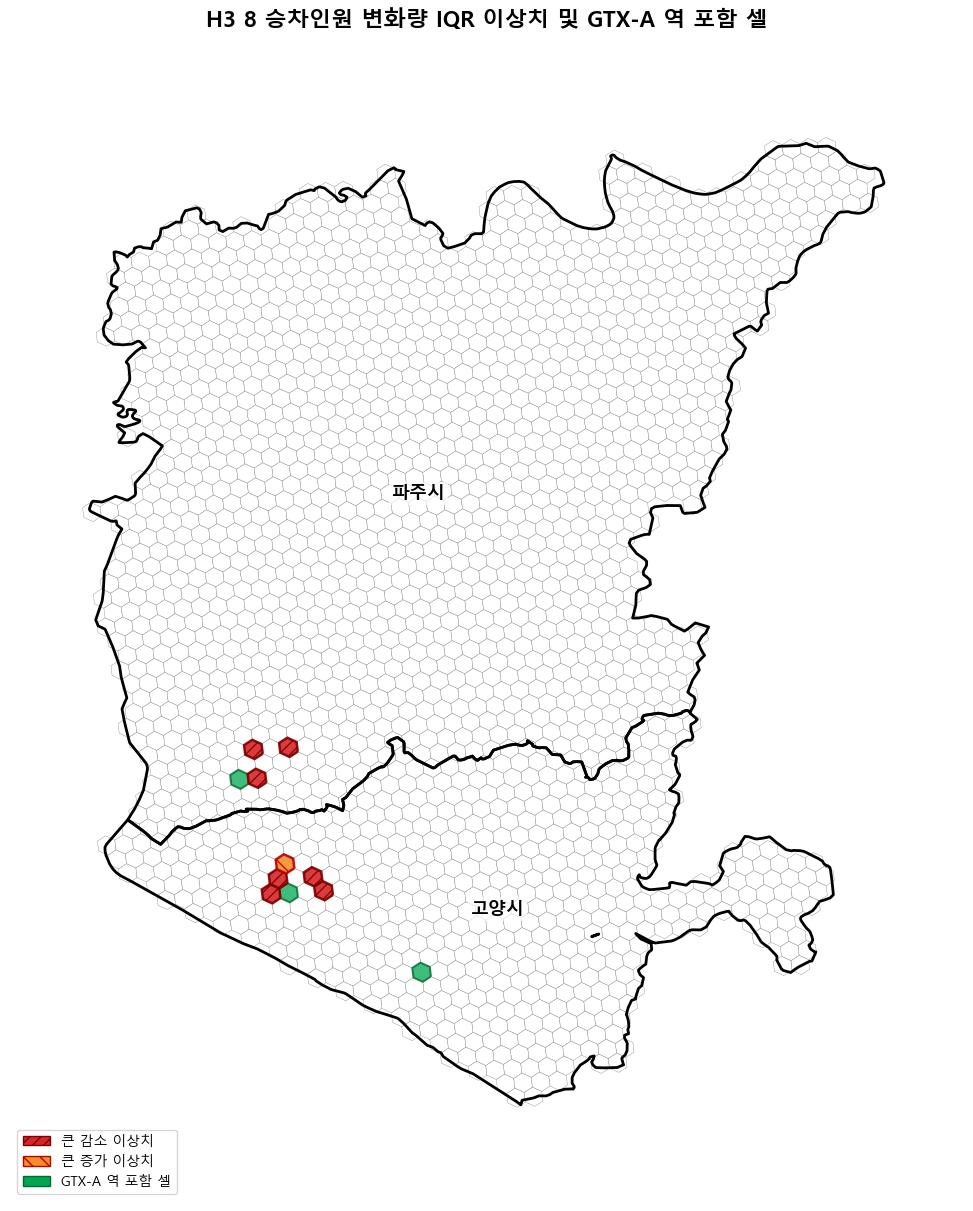

In [13]:
def h3_polygon(cell):
    boundary = h3.cell_to_boundary(cell) if hasattr(h3, 'cell_to_boundary') else h3.h3_to_geo_boundary(cell)
    return Polygon([(lon, lat) for lat, lon in boundary])
admin = gpd.read_file(ADMIN_PATH)
admin['sgg_code'] = admin['sgg'].astype(str).str.zfill(5)
admin['city'] = np.select([admin['sgg_code'].str.startswith('4128'), admin['sgg_code'].str.startswith('4148')], ['고양시', '파주시'], default='기타')
target_cities = admin[admin['city'] != '기타'].dissolve(by='city').reset_index()
target_geometry = target_cities.geometry.union_all() if hasattr(target_cities.geometry, 'union_all') else target_cities.geometry.unary_union
city_cells = sorted(h3.geo_to_cells(mapping(target_geometry), 8), key=str)
cell_gdf = gpd.GeoDataFrame({'H3 셀': city_cells}, geometry=[h3_polygon(cell) for cell in city_cells], crs='EPSG:4326')
gtx_stations = pd.DataFrame({'역명': ['운정중앙', '킨텍스', '대곡'], 'lat': [37.716670, 37.665000, 37.631626], 'lon': [126.728330, 126.748060, 126.811024]})
def latlon_to_h3(lat, lon):
    return h3.latlng_to_cell(float(lat), float(lon), 8) if hasattr(h3, 'latlng_to_cell') else h3.geo_to_h3(float(lat), float(lon), 8)
gtx_cells = {latlon_to_h3(row.lat, row.lon) for row in gtx_stations.itertuples()}
outlier_cells = set(outliers['H3 셀'])
outlier_lookup = outliers.set_index('H3 셀')['이상치 유형'].to_dict()
cell_gdf['이상치 유형'] = cell_gdf['H3 셀'].map(outlier_lookup).fillna('정상')
fig, ax = plt.subplots(figsize=(14, 12), constrained_layout=True)
cell_gdf.plot(ax=ax, facecolor='white', edgecolor='#777777', linewidth=0.25)
station_cells = cell_gdf[cell_gdf['H3 셀'].isin(gtx_cells)]
station_cells.plot(ax=ax, facecolor='#00A651', edgecolor='#006B2C', alpha=0.75, linewidth=1.5, zorder=3)
decrease_outliers = cell_gdf[cell_gdf['이상치 유형'] == '큰 감소 이상치']
increase_outliers = cell_gdf[cell_gdf['이상치 유형'] == '큰 증가 이상치']
if len(decrease_outliers): decrease_outliers.plot(ax=ax, facecolor='#D62728', edgecolor='#7F0000', hatch='///', alpha=0.9, linewidth=1.8, zorder=5)
if len(increase_outliers): increase_outliers.plot(ax=ax, facecolor='#F28E2B', edgecolor='#C00000', hatch='\\\\', alpha=0.9, linewidth=1.8, zorder=5)
target_cities.boundary.plot(ax=ax, color='black', linewidth=2.0, zorder=6)
for _, row in target_cities.iterrows():
    point = row.geometry.representative_point()
    ax.text(point.x, point.y, row['city'], fontsize=13, fontweight='bold', ha='center', va='center', bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.7, 'pad': 2}, zorder=7)
minx, miny, maxx, maxy = target_cities.total_bounds
padx, pady = max((maxx - minx) * 0.10, 0.02), max((maxy - miny) * 0.10, 0.02)
ax.set_xlim(minx - padx, maxx + padx)
ax.set_ylim(miny - pady, maxy + pady)
ax.set_aspect('equal')
legend_handles = [Patch(facecolor='#D62728', edgecolor='#7F0000', hatch='///', label='큰 감소 이상치'), Patch(facecolor='#F28E2B', edgecolor='#C00000', hatch='\\\\', label='큰 증가 이상치'), Patch(facecolor='#00A651', edgecolor='#006B2C', label='GTX-A 역 포함 셀')]
ax.legend(handles=legend_handles, loc='lower left', frameon=True)
ax.set_title('H3 8 승차인원 변화량 IQR 이상치 및 GTX-A 역 포함 셀', fontsize=16, fontweight='bold', pad=15)
ax.set_axis_off()
plt.show()

## 증가 이상치 셀의 노선·정류장 구성 확인

승차인원 증가 이상치 셀에 포함된 2024·2025년 노선과 정류장을 비교한다.

In [14]:
TRANSPORT = BASE / 'gtx_a_seoul_bus_outputs' / 'transport_card'
FILE_2024 = TRANSPORT / 'gtx_a_transport_card_20241017_raw_with_coords_api_filled.csv'
FILE_2025 = TRANSPORT / 'gtx_a_transport_card_20251016_raw_with_coords.csv'
def read_stop_records(path, year):
    raw = pd.read_csv(path, encoding='utf-8-sig', low_memory=False)
    df = raw.iloc[:, :13].copy()
    df.columns = ['query_date', 'route_no', 'route_id', 'stop_id', 'stop_name', 'stop_seq', 'lat', 'lon', 'goff_stop_id', 'goff_stop_name', 'goff_stop_seq', 'goff_lat', 'goff_lon']
    for col in ['route_no', 'route_id', 'stop_name']:
        df[col] = df[col].astype(str).str.strip()
    for col in ['stop_id', 'lat', 'lon']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df.dropna(subset=['stop_id', 'lat', 'lon']).copy()
    df['year'] = year
    return df
records = pd.concat([read_stop_records(FILE_2024, 2024), read_stop_records(FILE_2025, 2025)], ignore_index=True)
def cell_from_latlon(row):
    return h3.latlng_to_cell(float(row['lat']), float(row['lon']), 8) if hasattr(h3, 'latlng_to_cell') else h3.geo_to_h3(float(row['lat']), float(row['lon']), 8)
records['H3 셀'] = records.apply(cell_from_latlon, axis=1)
outlier_stop_detail = records[records['H3 셀'] == '8830e0b595fffff'].drop_duplicates(['year', 'route_no', 'stop_id']).sort_values(['year', 'route_no', 'stop_id'])
display(outlier_stop_detail[['year', 'route_no', 'route_id', 'stop_id', 'stop_name', 'lat', 'lon']])
display(outlier_stop_detail.groupby('year').agg(노선수=('route_no', 'nunique'), 정류장수=('stop_id', 'nunique')).reset_index())

,year,route_no,route_id,stop_id,stop_name,lat,lon
4746,2024,1500,41016044,4110873,농수산물센터,37.681933,126.746217
9886,2024,M7731,41016902,4106836,대화역,37.676367,126.747500
16068,2025,1500,41016044,4110873,농수산물센터,37.681933,126.746217
20767,2025,M7731,41016902,4106836,대화역,37.676367,126.747500


,year,노선수,정류장수
0,2024,2,2
1,2025,2,2


## 증가 이상치 셀의 노선·정류장별 승차인원

증가 이상치 셀에서 노선별·정류장별 승차인원을 집계한다.

In [15]:
def boarding_by_route_stop(path, year):
    raw = pd.read_csv(path, encoding='utf-8-sig', low_memory=False)
    route_no = raw.iloc[:, 1].astype(str).str.strip()
    stop_id = pd.to_numeric(raw.iloc[:, 22], errors='coerce')
    stop_name = raw.iloc[:, 4].astype(str).str.strip()
    lat = pd.to_numeric(raw.iloc[:, 6], errors='coerce')
    lon = pd.to_numeric(raw.iloc[:, 7], errors='coerce')
    users = pd.to_numeric(raw.iloc[:, 27], errors='coerce').fillna(0)
    data = pd.DataFrame({'연도': year, '노선번호': route_no, '정류장 ID': stop_id, '정류장명': stop_name, 'lat': lat, 'lon': lon, '승차인원': users}).dropna(subset=['정류장 ID', 'lat', 'lon'])
    data['H3 셀'] = data.apply(lambda row: latlon_to_h3(row['lat'], row['lon']), axis=1)
    data = data[data['H3 셀'] == '8830e0b595fffff']
    return data.groupby(['연도', '노선번호', '정류장 ID', '정류장명'], as_index=False)['승차인원'].sum().sort_values(['연도', '노선번호', '정류장 ID'])
boarding_detail = pd.concat([boarding_by_route_stop(FILE_2024, 2024), boarding_by_route_stop(FILE_2025, 2025)], ignore_index=True)
display(boarding_detail)

,연도,노선번호,정류장 ID,정류장명,승차인원
0,2024,1500,4110873,농수산물센터,29
1,2024,M7731,4106836,대화역,867
2,2025,1500,4110873,농수산물센터,32
3,2025,M7731,4106836,대화역,1570


## M7731 대화역 이상치 원인 확인

2024년 10월 17일과 2025년 10월 16일의 M7731 주요 정류장 수요, 중복 여부, 지역코드, 하차 목적지를 확인한다.


In [16]:
# 1. M7731 주요 정류장별 승차인원 비교
def load_m7731(path, year):
    raw = pd.read_csv(path, encoding='utf-8-sig', low_memory=False)
    df = raw[raw['query_route_no'].astype(str).str.strip().eq('M7731')].copy()
    df['year'] = year
    df['boarding_users'] = pd.to_numeric(df['utztn_nope'], errors='coerce').fillna(0)
    return df

m7731_2024 = load_m7731(FILE_2024, 2024)
m7731_2025 = load_m7731(FILE_2025, 2025)

target_stops = {
    '4106836': '대화역',
    '4177532': '킨텍스',
    '4177448': '킨텍스역·더샵그라비스타·힐스테이트일산',
}
rows = []
for stop_id, stop_name in target_stops.items():
    r24 = m7731_2024[m7731_2024['ride_sttn_id'].astype(str).eq(stop_id)]['boarding_users'].sum()
    r25 = m7731_2025[m7731_2025['ride_sttn_id'].astype(str).eq(stop_id)]['boarding_users'].sum()
    rows.append({'정류장 ID': stop_id, '정류장명': stop_name, '2024 승차인원': r24, '2025 승차인원': r25, '증감': r25 - r24})
stop_compare = pd.DataFrame(rows)
display(stop_compare)
print('세 정류장 합계')
display(stop_compare[['2024 승차인원', '2025 승차인원', '증감']].sum().to_frame().T)


,정류장 ID,정류장명,2024 승차인원,2025 승차인원,증감
0,4106836,대화역,867,1570,703
1,4177532,킨텍스,1036,424,-612
2,4177448,킨텍스역·더샵그라비스타·힐스테이트일산,874,872,-2


세 정류장 합계


,2024 승차인원,2025 승차인원,증감
0,2777,2866,89


In [17]:
# 2. 중복집계 및 승·하차 지역코드 검증
for label, df in [('2024-10-17', m7731_2024), ('2025-10-16', m7731_2025)]:
    print(f'===== {label} =====')
    print('승차 지역코드:', df['ride_ctpv_cd'].astype(str).str.zfill(2).value_counts().to_dict())
    print('하차 지역코드:', df['goff_ctpv_cd'].astype(str).str.zfill(2).value_counts().to_dict())
    print('원자료 행 수:', len(df))
    print('이용인원 합계:', int(df['boarding_users'].sum()))
    print('완전 중복 행 수:', int(df.duplicated().sum()))
    print('카드번호·승차시각 중복 수:', int(df.duplicated(['vr_card_no', 'ride_dt']).sum()))


===== 2024-10-17 =====
승차 지역코드: {'41': 1325}
하차 지역코드: {'11': 1325}
원자료 행 수: 1325
이용인원 합계: 3271
완전 중복 행 수: 0
카드번호·승차시각 중복 수: 0
===== 2025-10-16 =====
승차 지역코드: {'41': 1459}
하차 지역코드: {'11': 1459}
원자료 행 수: 1459
이용인원 합계: 3595
완전 중복 행 수: 0
카드번호·승차시각 중복 수: 0


In [18]:
# 3. 대화역 승차객의 시간대·하차 정류장 분포
daehwa_2024 = m7731_2024[m7731_2024['ride_sttn_id'].astype(str).eq('4106836')].copy()
daehwa_2025 = m7731_2025[m7731_2025['ride_sttn_id'].astype(str).eq('4106836')].copy()

for label, df in [('2024-10-17', daehwa_2024), ('2025-10-16', daehwa_2025)]:
    df['승차시각'] = pd.to_datetime(df['ride_dt'].astype(str), format='%Y%m%d%H%M%S', errors='coerce')
    print(f'===== {label} 대화역 시간대별 승차인원 =====')
    hourly = df.assign(시간=df['승차시각'].dt.hour).groupby('시간')['boarding_users'].sum().astype(int)
    display(hourly.rename('승차인원').to_frame())
    print(f'===== {label} 대화역 승차객 하차 정류장 =====')
    # API 원자료에는 하차 정류장명이 없을 수 있으므로 ID 기준으로 집계하고, 이름 컬럼이 있을 때만 함께 표시한다.
    name_col = next((c for c in ['goff_sttn_name', 'goff_stop_name', '하차정류장명'] if c in df.columns), None)
    id_col = 'goff_sttn_id' if 'goff_sttn_id' in df.columns else 'goff_stop_id'
    destination_cols = [id_col] + ([name_col] if name_col else [])
    destinations = (df.groupby(destination_cols, dropna=False)['boarding_users']
                      .sum().sort_values(ascending=False).astype(int).rename('승차인원').to_frame())
    display(destinations)


===== 2024-10-17 대화역 시간대별 승차인원 =====


,승차인원
시간,
0,5
5,15
6,50
7,56
8,64
9,43
10,41
11,36
12,45


===== 2024-10-17 대화역 승차객 하차 정류장 =====


,,승차인원
goff_sttn_id,하차정류장명,
4111588,합정역,505
4116126,홍대입구역(중),250
4116130,신촌오거리.현대백화점(중),65
4109162,공덕역1번출구,22
4111599,서강대후문.마포아트센터,13
4111598,이화여대입구,12


===== 2025-10-16 대화역 시간대별 승차인원 =====


,승차인원
시간,
0,13
5,31
6,78
7,114
8,73
9,56
10,70
11,87
12,87


===== 2025-10-16 대화역 승차객 하차 정류장 =====


,,승차인원
goff_sttn_id,하차정류장명,
4111588,합정역,834
4116126,홍대입구역(중),498
4116130,신촌오거리.현대백화점(중),148
4109162,공덕역1번출구,46
4111599,서강대후문.마포아트센터,27
4111598,이화여대입구,17


## 10월 행사일과 11월 목요일 비교

10월 16일·30일 행사일과 11월 목요일의 M7731 수요 차이를 비교한다.


,날짜,요일,M7731 전체 승차인원,대화역 승차인원,킨텍스 승차인원,구분
0,2025-10-16,Thursday,3595,1570,424,행사일
1,2025-10-23,Thursday,3608,1478,546,11월 목요일
2,2025-10-30,Thursday,3451,1200,714,행사일
3,2025-11-06,Thursday,1320,412,266,11월 목요일
4,2025-11-13,Thursday,1332,448,263,11월 목요일
5,2025-11-20,Thursday,1294,473,176,11월 목요일
6,2025-11-27,Thursday,1252,465,159,11월 목요일


행사일과 11월 목요일 평균 비교


,"행사일 평균 (10/16, 10/30)",11월 목요일 평균,행사일 평균 - 11월 평균
M7731 전체 승차인원,3523.0,1761.2,1761.8
대화역 승차인원,1385.0,655.2,729.8
킨텍스 승차인원,569.0,282.0,287.0


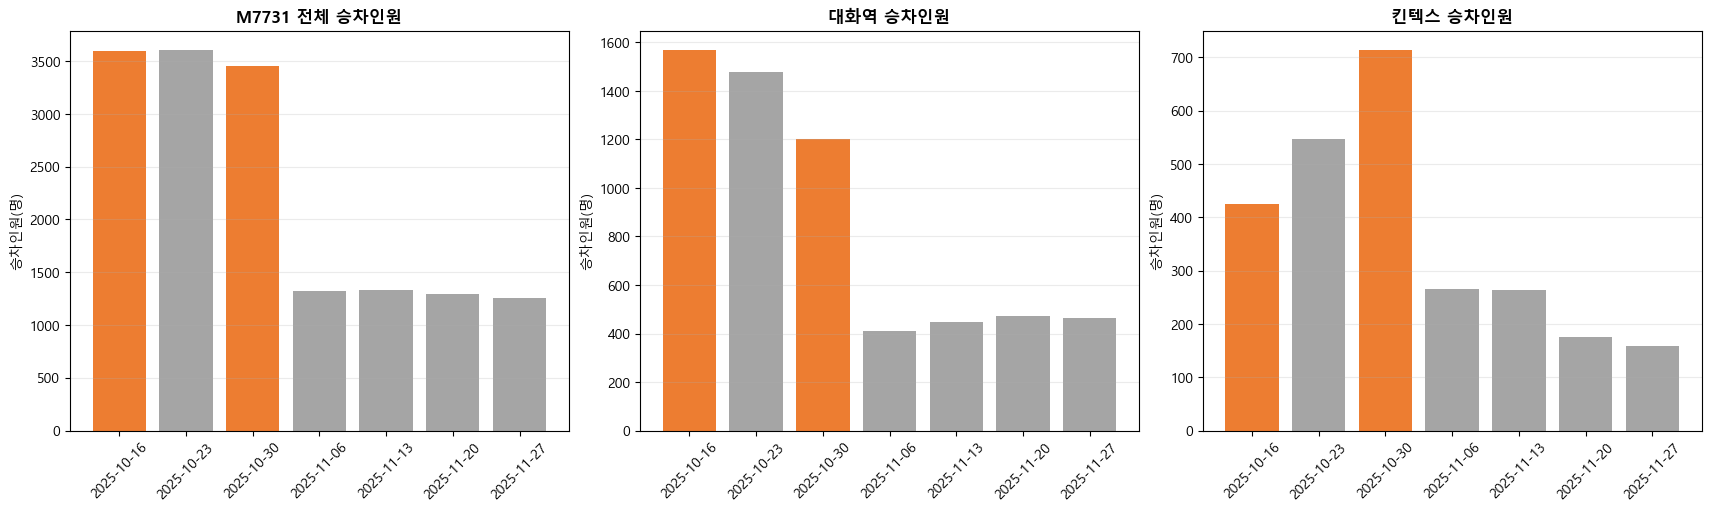

In [31]:
# 5. October event dates versus November Thursdays
from pathlib import Path

project_root = Path.cwd()
if not (project_root / 'gtx_a_seoul_bus_outputs').exists():
    project_root = project_root.parent
transport_dir = project_root / 'gtx_a_seoul_bus_outputs' / 'transport_card'
date_files = {
    '2025-10-23': transport_dir / 'gtx_a_transport_card_20251023_M7731_raw.csv',
    '2025-10-30': transport_dir / 'gtx_a_transport_card_20251030_M7731_raw.csv',
    '2025-11-06': transport_dir / 'gtx_a_transport_card_20251106_M7731_raw.csv',
    '2025-11-13': transport_dir / 'gtx_a_transport_card_20251113_M7731_raw.csv',
    '2025-11-20': transport_dir / 'gtx_a_transport_card_20251120_M7731_raw.csv',
    '2025-11-27': transport_dir / 'gtx_a_transport_card_20251127_M7731_raw.csv',
}
date_dfs = {'2025-10-16': m7731_2025.copy()}
for date, path in date_files.items():
    date_dfs[date] = pd.read_csv(path, encoding='utf-8-sig', low_memory=False)

summary_rows = []
for date, df in date_dfs.items():
    daehwa = df[df['ride_sttn_id'].astype(str).eq('4106836')]['utztn_nope'].sum()
    kintex = df[df['ride_sttn_id'].astype(str).eq('4177532')]['utztn_nope'].sum()
    summary_rows.append({
        '날짜': date,
        '요일': pd.Timestamp(date).day_name(),
        'M7731 전체 승차인원': int(df['utztn_nope'].sum()),
        '대화역 승차인원': int(daehwa),
        '킨텍스 승차인원': int(kintex),
    })

date_summary = pd.DataFrame(summary_rows).sort_values('날짜').reset_index(drop=True)
date_summary['구분'] = date_summary['날짜'].isin(['2025-10-16', '2025-10-30']).map({True: '행사일', False: '11월 목요일'})
display(date_summary)

event_dates = date_summary[date_summary['구분'].eq('행사일')]
nov_dates = date_summary[date_summary['구분'].eq('11월 목요일')]
group_compare = pd.DataFrame({
    '행사일 평균 (10/16, 10/30)': event_dates[['M7731 전체 승차인원', '대화역 승차인원', '킨텍스 승차인원']].mean(),
    '11월 목요일 평균': nov_dates[['M7731 전체 승차인원', '대화역 승차인원', '킨텍스 승차인원']].mean(),
})
group_compare['행사일 평균 - 11월 평균'] = group_compare.iloc[:, 0] - group_compare.iloc[:, 1]
print('행사일과 11월 목요일 평균 비교')
display(group_compare.round(1))

fig, axes = plt.subplots(1, 3, figsize=(17, 5), constrained_layout=True)
metrics = ['M7731 전체 승차인원', '대화역 승차인원', '킨텍스 승차인원']
for ax, metric in zip(axes, metrics):
    colors = ['#ED7D31' if x in ['2025-10-16', '2025-10-30'] else '#A5A5A5' for x in date_summary['날짜']]
    ax.bar(date_summary['날짜'], date_summary[metric], color=colors)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylabel('승차인원(명)')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.25)
plt.show()
